# Beispiel BESS-Optimierung am Day-Ahead-Markt für eine Woche


---

<span style="color:#ffffff; font-weight:400; background:rgba(66, 165, 245, 0.28); padding:2px 6px; border-radius:5px;">Day-Ahead-Markt</span>(EPEX Spot): Strom wird für den nächsten Tag gehandelt → Angebot und Nachfrage bestimmen den Preis [EUR/MWh]stündlich (in Deutschland seit 2023 auch in 15-Minuten-Auflösung)

<span style="color:#ffffff; font-weight:400; background:rgba(66, 165, 245, 0.28); padding:2px 6px; border-radius:5px;">Arbitrage-Handel</span>: Strom zu einem niedrigen Preis kaufen (Laden) und zu einem hohen Preis verkaufen (Entladen) → Gewinn =  Differenz minus Effizienzverluste


<div style="background:rgba(255,255,255,0.06); padding:12px 14px; border-radius:8px; border-left:4px solid rgba(255,213,79,0.7);">

<strong>Einordnung:</strong> Die Optimierung wird hier beispielhaft für eine ausgewählte Woche durchgeführt. Sie zeigt das Prinzip der Preisarbitrage, ersetzt aber keine vollständige Jahresanalyse.

</div>

<div style="background:rgba(255,255,255,0.06); padding:12px 14px; border-radius:8px; text-align:center; font-size:18px;">

$Nettoerlös = Erlöse_{Entladung} - Kosten_{Ladung}$

</div>

| Parameter | Bedeutung | Wert |
|---|---:|---:|
| $E_{max}$ | Speicherkapazität | 2 MWh |
| $P_{max}$ | Lade-/Entladeleistung | 1 MW |
| $\eta$ | Wirkungsgrad | 90 % |
| $SOC_{Start}$ | Startfüllstand | 1 MWh |
| $SOC_{Ende}$ | Endfüllstand | 1 MWh |

<div style="background:rgba(76,175,80,0.14); padding:12px 14px; border-radius:8px; border-left:4px solid rgba(76,175,80,0.8);">

<strong>Ergebnis:</strong> Der Batteriespeicher erzielt in der Beispielwoche einen Nettoerlös von <strong>1.892,50 €</strong>.  
Das Modell lädt überwiegend bei niedrigen Preisen und entlädt bei höheren Preisen.

</div>

---
## 1 · Daten laden und prüfen

In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 110

In [2]:
df_raw = pd.read_csv('../daten/dayahead_2025.csv')
print('Spaltennamen:', df_raw.columns.tolist())
df_raw.head()

Spaltennamen: ['timestamp', 'dayahead €/MWh']


,timestamp,dayahead €/MWh
0,2024-12-31 23:00:00+00:00,22.40
1,2024-12-31 23:15:00+00:00,-7.40
2,2024-12-31 23:30:00+00:00,-10.16
3,2024-12-31 23:45:00+00:00,-5.30
4,2025-01-01 00:00:00+00:00,5.54


In [3]:
# Zeitstempel parsen und als Index setzen
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], utc=True)
df_raw = df_raw.set_index('timestamp')
# Lokale Berliner Zeit, tz-naive (PyPSA-Anforderung); sort_index wegen Sommerzeit-Überlappung
df_raw.index = df_raw.index.tz_convert('Europe/Berlin').tz_localize(None)
df_raw = df_raw.sort_index()
df_raw.columns = ['price_eur_mwh']

print(f'Zeitraum : {df_raw.index.min()}  →  {df_raw.index.max()}')
print(f'Zeitschritte : {len(df_raw):,}  (15-Minuten-Auflösung)')
print(f'Preis [EUR/MWh] : min {df_raw.price_eur_mwh.min():.2f}  |  max {df_raw.price_eur_mwh.max():.2f}  |  Ø {df_raw.price_eur_mwh.mean():.2f}')
df_raw.info()

Zeitraum : 2025-01-01 00:00:00  →  2025-12-31 23:45:00
Zeitschritte : 35,040  (15-Minuten-Auflösung)
Preis [EUR/MWh] : min -499.99  |  max 834.60  |  Ø 89.71
<class 'pandas.DataFrame'>
DatetimeIndex: 35040 entries, 2025-01-01 00:00:00 to 2025-12-31 23:45:00
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price_eur_mwh  35040 non-null  float64
dtypes: float64(1)
memory usage: 547.5 KB


> **Einheit:** EUR/MWh – der Preis pro Megawattstunde gelieferter oder abgenommener Energie.  
> **15-Minuten-Auflösung:** 1 Zeitschritt entspricht 0,25 Stunden → Energie = Leistung × 0,25 h.

---
## 2 · Beispielwoche auswählen

Wir wählen **13.–19. Januar 2025** (Kalenderwoche 3).  
Diese Woche zeigt einen ausgeprägten Preisunterschied zwischen Tag und Nacht – ideal für Arbitrage.

In [4]:
week = df_raw['2025-01-13':'2025-01-19 23:45'].copy()

print(f'Zeitschritte in der Woche : {len(week)}')
print(f'Preisspanne               : {week.price_eur_mwh.min():.2f} – {week.price_eur_mwh.max():.2f} EUR/MWh')
week.head(8)

Zeitschritte in der Woche : 672
Preisspanne               : 71.35 – 542.77 EUR/MWh


,price_eur_mwh
timestamp,
2025-01-13 00:00:00,122.2
2025-01-13 00:15:00,112.6
2025-01-13 00:30:00,103.3
2025-01-13 00:45:00,86.3
2025-01-13 01:00:00,113.5
2025-01-13 01:15:00,104.4
2025-01-13 01:30:00,99.6
2025-01-13 01:45:00,93.5


---
## 3 · Day-Ahead-Preis der Beispielwoche visualisieren

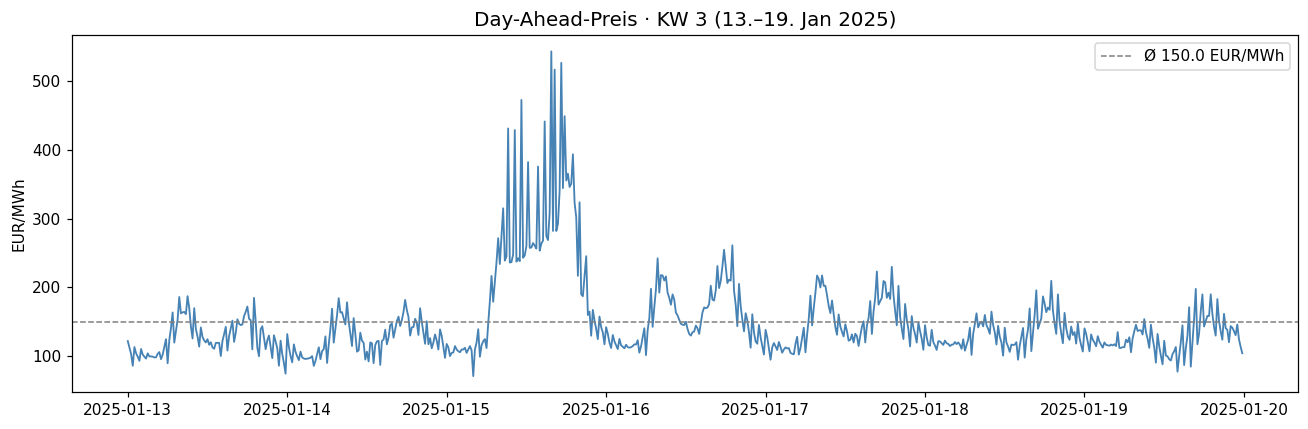

In [5]:
fig, ax = plt.subplots()
ax.plot(week.index, week.price_eur_mwh, color='steelblue', lw=1.2)
ax.axhline(week.price_eur_mwh.mean(), color='gray', ls='--', lw=1, label=f'Ø {week.price_eur_mwh.mean():.1f} EUR/MWh')
ax.set_title('Day-Ahead-Preis · KW 3 (13.–19. Jan 2025)', fontsize=13)
ax.set_ylabel('EUR/MWh')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**  
- **Niedrige Preise** (Nacht, Wochenende) → Batterie **laden** (günstig einkaufen).  
- **Hohe Preise** (Morgenpeak, Abendpeak) → Batterie **entladen** (teuer verkaufen).  

Das Optimierungsmodell findet automatisch die beste Kombination.

---
## 4 · Batterieparameter definieren

In [6]:
# ── Technische Parameter ──────────────────────────────────────────────────────
CAPACITY_MWH      = 2.0   # Speicherkapazität [MWh]
CHARGE_MW         = 1.0   # Max. Ladeleistung [MW]
DISCHARGE_MW      = 1.0   # Max. Entladeleistung [MW]
EFF_CHARGE        = 0.90  # Wirkungsgrad Laden [-]
EFF_DISCHARGE     = 0.90  # Wirkungsgrad Entladen [-]
SOC_START_MWH     = 1.0   # Anfangs-SOC [MWh]
SOC_END_MWH       = 1.0   # End-SOC [MWh]  (= Start-SOC: verhindert künstl. Leerfahren)

DT = 0.25  # Zeitschrittlänge [h] bei 15-Minuten-Daten

print('Batterieparameter:')
print(f'  Kapazität        : {CAPACITY_MWH} MWh')
print(f'  Ladeleistung     : {CHARGE_MW} MW')
print(f'  Entladeleistung  : {DISCHARGE_MW} MW')
print(f'  η Laden          : {EFF_CHARGE*100:.0f} %')
print(f'  η Entladen       : {EFF_DISCHARGE*100:.0f} %')
print(f'  SOC Start / Ende : {SOC_START_MWH} / {SOC_END_MWH} MWh')

Batterieparameter:
  Kapazität        : 2.0 MWh
  Ladeleistung     : 1.0 MW
  Entladeleistung  : 1.0 MW
  η Laden          : 90 %
  η Entladen       : 90 %
  SOC Start / Ende : 1.0 / 1.0 MWh


> **SOC (State of Charge):** der aktuelle Ladezustand der Batterie in MWh, begrenzt auf 0 ≤ SOC ≤ 2 MWh.  
> **End-SOC = Start-SOC:** Das Modell darf den Speicher am Ende der Woche nicht leer verkaufen, um künstliche Zusatzerlöse zu vermeiden.

---
## 5 · PyPSA-Modell aufbauen

In [7]:
# ── Network erstellen ─────────────────────────────────────────────────────────
n = pypsa.Network()
n.set_snapshots(week.index)

# 15-Minuten-Schritte: jeder Snapshot zählt 0,25 Stunden
n.snapshot_weightings[:] = DT

# ── Carrier & Bus ─────────────────────────────────────────────────────────────
n.add('Carrier', 'electricity')
n.add('Bus', 'Strommarkt', carrier='electricity')

# ── Markt-Generator: repräsentiert den Day-Ahead-Markt ───────────────────────
# p_min_pu=-1 erlaubt negativen Einsatz (= Verkauf an den Markt).
# Busbalanz: p_markt = p_store − p_dispatch
# Objective-Beitrag: Σ price · p_markt · dt = Ladekosten − Entladeerlöse
# PyPSA minimiert die Gesamtkosten → maximiert automatisch den Nettoerlös.
prices = week['price_eur_mwh']

n.add('Generator', 'Markt',
    bus          = 'Strommarkt',
    carrier      = 'electricity',
    p_nom        = 999,    # unbegrenzte Marktkapazität
    p_min_pu     = -1,     # kann Strom kaufen (pos.) und verkaufen (neg.)
    marginal_cost = prices  # Day-Ahead-Preis in EUR/MWh
)

# ── StorageUnit: die Batterie ─────────────────────────────────────────────────
# state_of_charge_initial und state_of_charge sind in PyPSA ≥1.x in MWh (absolut).
n.add('StorageUnit', 'Batterie',
    bus                  = 'Strommarkt',
    carrier              = 'electricity',
    p_nom                = DISCHARGE_MW,
    max_hours            = CAPACITY_MWH / DISCHARGE_MW,
    efficiency_store     = EFF_CHARGE,
    efficiency_dispatch  = EFF_DISCHARGE,
    state_of_charge_initial = SOC_START_MWH,  # MWh (absolut)
    cyclic_state_of_charge  = False,
)

# End-SOC erzwingen: letzter Zeitschritt muss SOC_END_MWH erreichen
n.storage_units_t['state_of_charge_set'] = pd.DataFrame(
    index=week.index, columns=['Batterie'], data=float('nan')
)
n.storage_units_t['state_of_charge_set'].loc[week.index[-1], 'Batterie'] = SOC_END_MWH

print('PyPSA-Netzwerk aufgebaut.')
print(f'  Snapshots    : {len(n.snapshots)}')
print(f'  Komponenten  : {n.generators.index.tolist()} + {n.storage_units.index.tolist()}')

PyPSA-Netzwerk aufgebaut.
  Snapshots    : 672
  Komponenten  : ['Markt'] + ['Batterie']


---
## 6 · Optimierung durchführen

In [8]:
status, condition = n.optimize(solver_name='highs', solver_options={'output_flag': False})
print(f'Status    : {status}')
print(f'Condition : {condition}')

INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - output_flag: False


INFO:linopy.io: Writing time: 0.03s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2688 primals, 6721 duals
Objective: -1.89e+03
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-state_of_charge_set, StorageUnit-energy_balance were not assigned to the network.


Status    : ok
Condition : optimal


---
## 7 · Ergebnisse berechnen

In [9]:
# ── Zeitreihen aus dem optimierten Modell ────────────────────────────────────
p_dispatch = n.storage_units_t.p_dispatch['Batterie']   # Entladeleistung [MW]
p_store    = n.storage_units_t.p_store['Batterie']      # Ladeleistung (aus Bus) [MW]
soc        = n.storage_units_t.state_of_charge['Batterie']  # SOC [MWh], absolut in PyPSA ≥1.x

# ── Energiemengen [MWh] ───────────────────────────────────────────────────────
e_charged    = (p_store    * DT).sum()   # Energie aus dem Netz (Eingang Wechselrichter)
e_discharged = (p_dispatch * DT).sum()   # Energie ins Netz (Ausgang Wechselrichter)

# ── Erlöse und Kosten [EUR] ───────────────────────────────────────────────────
cost_charging  = (p_store    * prices * DT).sum()
rev_discharge  = (p_dispatch * prices * DT).sum()
net_revenue    = rev_discharge - cost_charging

# ── Durchschnittspreise und Spread ───────────────────────────────────────────
avg_charge_price    = cost_charging  / e_charged    if e_charged    > 0 else 0
avg_discharge_price = rev_discharge  / e_discharged if e_discharged > 0 else 0
realized_spread     = avg_discharge_price - avg_charge_price

print('═' * 48)
print('  ERGEBNISSE  (KW 3 · 13.–19. Jan 2025)')
print('═' * 48)
print(f'  Geladene Energie        : {e_charged:.2f} MWh')
print(f'  Entladene Energie       : {e_discharged:.2f} MWh')
print(f'  Ø Ladepreis             : {avg_charge_price:.2f} EUR/MWh')
print(f'  Ø Entladepreis          : {avg_discharge_price:.2f} EUR/MWh')
print(f'  Realisierter Spread     : {realized_spread:.2f} EUR/MWh')
print('─' * 48)
print(f'  Ladekosten              : {cost_charging:.2f} EUR')
print(f'  Entladeerlöse           : {rev_discharge:.2f} EUR')
print(f'  ► Nettoerlös            : {net_revenue:.2f} EUR')
print('═' * 48)

════════════════════════════════════════════════
  ERGEBNISSE  (KW 3 · 13.–19. Jan 2025)
════════════════════════════════════════════════
  Geladene Energie        : 41.19 MWh
  Entladene Energie       : 33.37 MWh
  Ø Ladepreis             : 119.67 EUR/MWh
  Ø Entladepreis          : 204.46 EUR/MWh
  Realisierter Spread     : 84.79 EUR/MWh
────────────────────────────────────────────────
  Ladekosten              : 4929.33 EUR
  Entladeerlöse           : 6821.84 EUR
  ► Nettoerlös            : 1892.50 EUR
════════════════════════════════════════════════


---
## 8 · Ergebnisse visualisieren

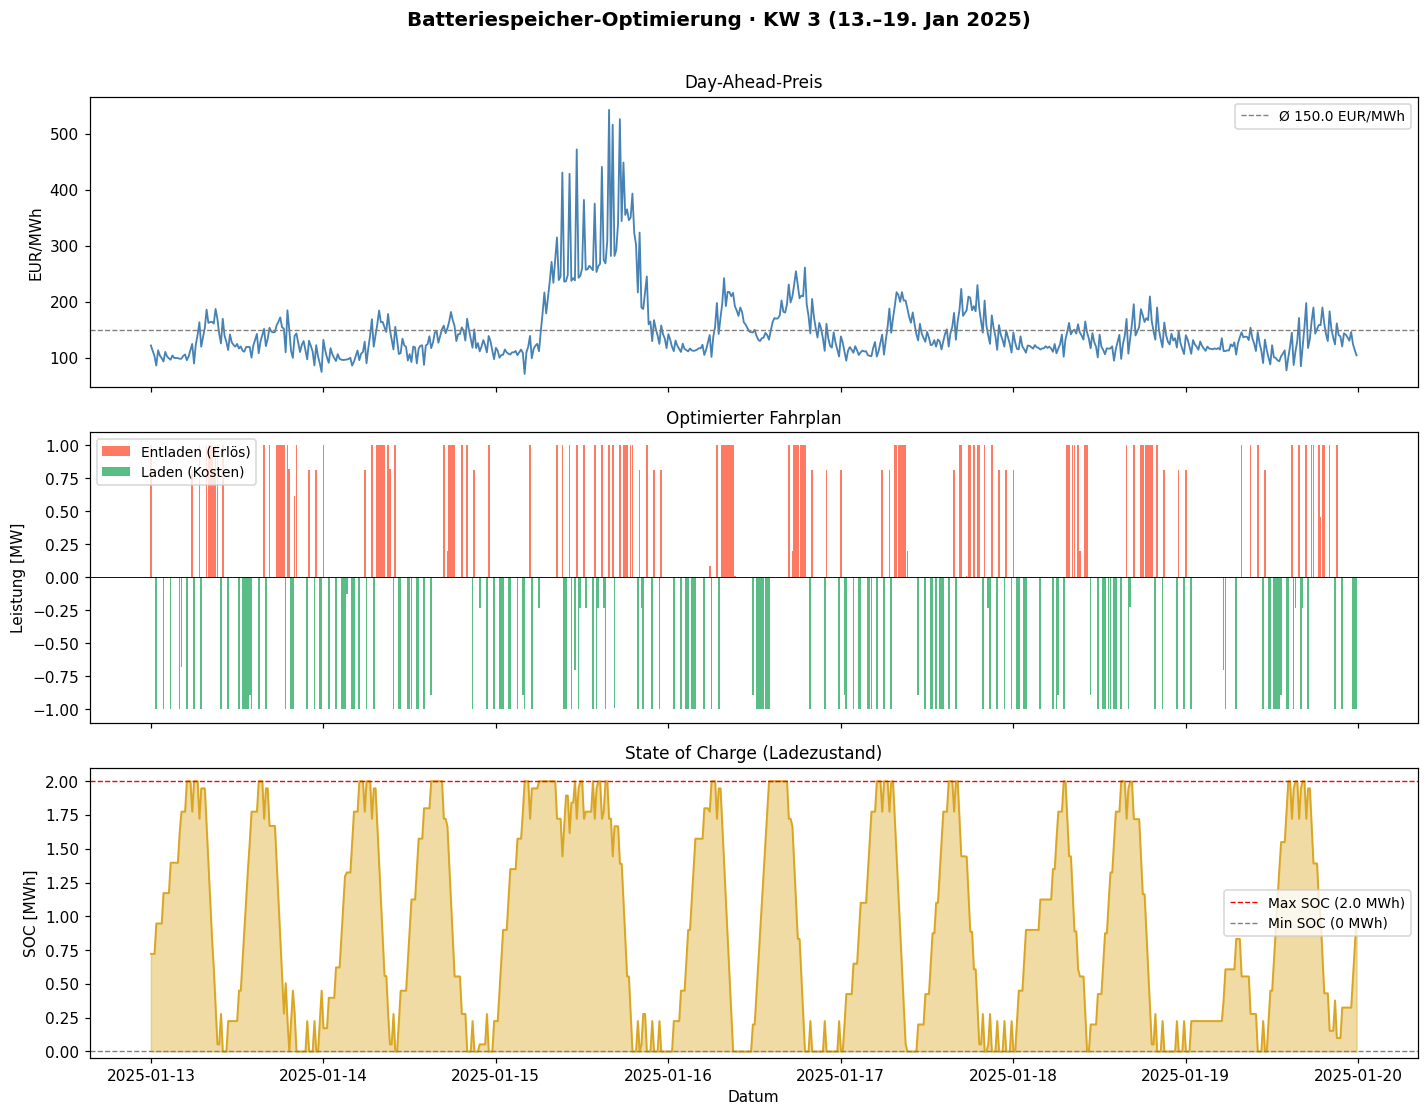

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# ── Plot 1: Day-Ahead-Preis ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(week.index, prices, color='steelblue', lw=1.2)
ax.axhline(prices.mean(), color='gray', ls='--', lw=0.9, label=f'Ø {prices.mean():.1f} EUR/MWh')
ax.set_ylabel('EUR/MWh')
ax.set_title('Day-Ahead-Preis', fontsize=11)
ax.legend(fontsize=9)

# ── Plot 2: Lade- und Entladeleistung ─────────────────────────────────────────
ax = axes[1]
ax.bar(week.index, p_dispatch, width=pd.Timedelta('14min'),
       color='tomato', alpha=0.85, label='Entladen (Erlös)')
ax.bar(week.index, -p_store, width=pd.Timedelta('14min'),
       color='mediumseagreen', alpha=0.85, label='Laden (Kosten)')
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel('Leistung [MW]')
ax.set_title('Optimierter Fahrplan', fontsize=11)
ax.legend(fontsize=9)

# ── Plot 3: SOC-Verlauf ────────────────────────────────────────────────────────
ax = axes[2]
ax.fill_between(week.index, soc, alpha=0.4, color='goldenrod')
ax.plot(week.index, soc, color='goldenrod', lw=1.2)
ax.axhline(CAPACITY_MWH, color='red',  ls='--', lw=0.9, label=f'Max SOC ({CAPACITY_MWH} MWh)')
ax.axhline(0,            color='gray', ls='--', lw=0.9, label='Min SOC (0 MWh)')
ax.set_ylabel('SOC [MWh]')
ax.set_title('State of Charge (Ladezustand)', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(-0.05, CAPACITY_MWH + 0.1)

plt.xlabel('Datum')
plt.suptitle('Batteriespeicher-Optimierung · KW 3 (13.–19. Jan 2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9 · Fazit

**Was zeigt die Optimierung?**  
Das Modell findet automatisch den gewinnmaximalen Fahrplan: Die Batterie lädt in Phasen niedriger Preise und entlädt in Phasen hoher Preise.

**Warum lädt die Batterie bei niedrigen Preisen?**  
Der Day-Ahead-Preis ist die Grenzkosten des Ladens. Niedriger Preis → günstige Beschaffung.

**Warum entlädt sie bei hohen Preisen?**  
Entladen liefert Strom ins Netz zu dem Preis, den der Markt gerade zahlt. Hoher Preis → hoher Erlös.

**Warum Wochenmodell statt Jahresmodell für die Live-Demo?**  
Eine Woche hat 672 Zeitschritte → der Solver rechnet in Sekunden. Ein Jahresmodell (35 040 Zeitschritte) würde in der Live-Demo mehrere Minuten dauern.

**Ausblick:**  
Im vollständigen Projekt sind ein **Jahresmodell** (Summenerlöse, Vollzyklen, KPIs) und eine **Rolling-Horizon-Strategie** (ohne perfekte Preisvoraussicht) vorgesehen – werden aber nicht live gerechnet.